<a href="https://colab.research.google.com/github/carn51/Assignment-1/blob/main/2026_DSLab2_a3_bsw.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **DS Lab2 - Assignment 3: Making a Discovery in the AirBnB Dataset**

This is the final assessment for DSLab2, giving you chance to bring together the full skillset you have acquired over the course of the module. Note that this assignment makes up the final 40% of the grade for the module. \\

Please make sure you use the software versions specified in this notebook, rather than the latest or other versions.

**Task**

**Visit the Inside AirBnB website and choose at least 3 locations in Australia that you would be interested in comparing.** \\

(Note - if you have problems in Chrome try downloading in Safari or some other browser) \\

You may employ any of the tools we have encountered so far in the module. Choose or switch interchangably between Pandas, PySpark, Dask, and PyTorch, as well as all the usual Python packages (e.g. numpy, matplotlib), and string manipulation tools if required. \\

A greater degree of independence is expected in choosing the correct tools for a particular task in this assignment, and your analysis should be thorough and well documented. Marks will be assigned for the quality of your code, including clarity, commenting and appropriate visualisations e.g. histograms, scatterplots etc. \\

**To Submit:**

1.   **This notebook containing your code and visualizations**
      - Please name the file "YOUR_NAME_DSLab226_a3.ipynb" (i.e. update "YOUR NAME" to be your name...)
      - The file *must* be in .ipynb format - markers will check that your code runs successfully.

2.  **All data files that are needed to run your code**
      - e.g. If you work on the detailed reviews from Sydney, **you must submit the csv file** of Sydney's detailed reviews with your code and report so we can run the code.

3.   **1-page report summarising your work and findings**
      - Please name the file "YOUR_NAME_DSLab226_a3_report.pdf" (i.e. update "YOUR NAME" to be your name...)
      - The file *must* be submitted in PDF format - LaTEX is recommended to generate your report, but you will not be penalised for a well-presented Word document exported as a PDF.
      - Please aim to provide your full report within 2 sides of A4 (marks will be lost for reports less than 1 side of A4 or for reports greater than 2 sides of A4.)



# Setup

In [ ]:
## Generic setup that we have used every week - this time they need to set up themselves
## Mount your Google Drive so we can access the data
from google.colab import drive
drive.mount('/content/drive',  force_remount=True)

Mounted at /content/drive


In [ ]:
## Import useful python modules
import pandas as pd ## to read in and explore data
import numpy as np ## Useful for calculations
import matplotlib.pyplot as plt ## Useful for plotting
import matplotlib.gridspec as gridspec ## Useful for plotting

# Q1 - Classification Problem
**25 marks for developing appropriate code for the chosen problem**

**25 marks for a report documenting your choice of problem, motivation, rationale for the developed solution, results and conclusions**

Design and implement a classification problem that can be applied to each of your locations. You may focus on any problem that interests you, but make sure to include the following elements:


*   Clean the input dataframes by doing the following:

> Remove NaNs in your columns of interest \\
> Update the Dtype of any columns if necessary \\

*   Choose a suitable classification algorithm
*   Visualise the output of your classifications using at least one appropriate plot
*   Apply your technique to at least two different locations
*   Describe the problem, the approach you have chosen, and the results in your accompanying report
*   Remember to comment your code to help the markers (and yourself!). Think about using functions wherever appropriate to make it easier to apply your code to multiple locations for example. \\

\\

**If you require inspiration, perhaps consider one of the following problems**

(no marks gained or lost for using a suggested problem vs an original problem):

1.   By treating "`review_score_rating`" as a discrete variable (i.e. a series of distinct bins) construct a model to predict which of your chosen categories a given listing will fall into, e.g. excellent, good, intermediate, poor, rubbish or similar. \\

2.   Use sentiment analysis to classify reviews (i.e. "`comments`" column) into positive, neutral, or negative sentiment categories. Compare the overall satisfaction level with AirBnB listings across different cities (probably best to use at least 3 locations).  \\


Feel free to develop either of these ideas or one of your own, and see where the analysis takes you. You may find it helpful to start by mapping out in comments the broad-brush steps of your analysis, then think about how to accomplish each stage. \\

\\



# Load Data

In [79]:
## Load first chosen dataset into a Pandas (or PySpark/Dask) DataFrame

data = pd.read_csv('/content/listings_bsw.csv.gz')
df = pd.DataFrame(data)
df.head(3)

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,21302,https://www.airbnb.com/rooms/21302,20250928035044,2025-09-28,city scrape,Great Ocean Haven,If you are looking for a beach house to relax ...,We are situated minutes walking distance to th...,https://a0.muscache.com/pictures/hosting/Hosti...,81292,...,4.98,4.94,4.63,NaN,f,3,2,1,0,0.40
1,27561,https://www.airbnb.com/rooms/27561,20250928035044,2025-09-28,city scrape,Executive residence peaceful locale,A spacious retreat in a perfect location to re...,The area is generally quiet but seasonal touri...,https://a0.muscache.com/pictures/153948/809ee1...,119103,...,5.00,5.00,5.00,NaN,f,2,1,1,0,0.03
2,70449,https://www.airbnb.com/rooms/70449,20250928035044,2025-09-28,city scrape,Otway foothills retreat,"Modern 2 bedroom house with 2 bathrooms, kitch...",NaN,https://a0.muscache.com/pictures/450690/937a7e...,357052,...,4.94,4.83,4.67,NaN,f,1,1,0,0,0.50


Select important features

In [137]:
df1 = df[['host_since', 'price', 'beds', 'accommodates', 'reviews_per_month', 'review_scores_value', 'host_name', 'description']]    #host name for reference

# Clean Data

Feature Engineering

In [138]:
df1['price'] = df1['price'].str.replace('$', '').str.replace(',', '').astype(float)

from datetime import datetime

current = datetime.now()
df1['host_since'] = pd.to_datetime(df1['host_since'])
df1['host_exp'] = ((current - df1['host_since']) / pd.Timedelta(days= 365.25))

df1['host_exp'].head(3)
df1 = df1.drop(columns = ['host_since']).dropna()

/tmp/ipykernel_1655/242417254.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['price'] = df1['price'].str.replace('$', '').str.replace(',', '').astype(float)
/tmp/ipykernel_1655/242417254.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['host_since'] = pd.to_datetime(df1['host_since'])
/tmp/ipykernel_1655/242417254.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the do

Cleaning of text columns

In [139]:
import re

def clean_func(string):
  #ensure text is in fact strings
  text = str(string)
  #remove tags
  cleaner_text = re.sub('<[^<]+?>', '', text)
  full_clean_text = re.sub(r'[^a-zA-Z0-9\s]', '', cleaner_text)
  return full_clean_text

df1['clean_descs'] = df1['description'].apply(clean_func)
df2 =df1.drop(columns = ['description'])
df2.head(3)

,price,beds,accommodates,reviews_per_month,review_scores_value,host_name,host_exp,clean_descs
0,814.0,5.0,8,0.40,4.63,Laurel,16.193343,If you are looking for a beach house to relax ...
1,363.0,6.0,9,0.03,5.00,Lynn,15.977052,A spacious retreat in a perfect location to re...
2,156.0,3.0,6,0.50,4.67,Craig And Tim,15.259736,Modern 2 bedroom house with 2 bathrooms kitche...


In [140]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5603 entries, 0 to 7248
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   price                5603 non-null   float64
 1   beds                 5603 non-null   float64
 2   accommodates         5603 non-null   int64  
 3   reviews_per_month    5603 non-null   float64
 4   review_scores_value  5603 non-null   float64
 5   host_name            5603 non-null   object 
 6   host_exp             5603 non-null   float64
 7   clean_descs          5603 non-null   object 
dtypes: float64(5), int64(1), object(2)
memory usage: 394.0+ KB


Plots

In [149]:
df2_poor = df2[(df2['review_scores_value'] > 2) & (df2['review_scores_value'] < 3)]
df2_mid = df2[(df2['review_scores_value'] >= 3) & (df2['review_scores_value'] < 4)]
df2_good = df2[(df2['review_scores_value'] >= 4) & (df2['review_scores_value'] < 5)]

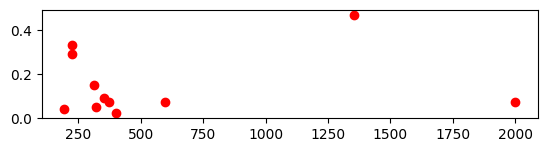

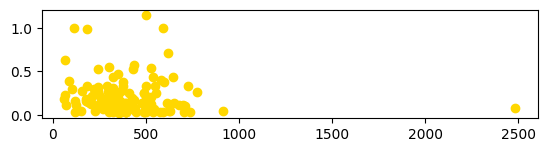

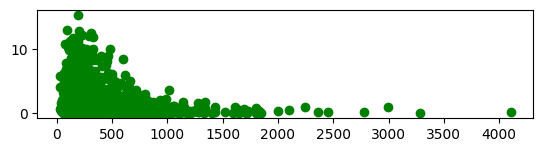

In [151]:
plt.subplot(3, 1, 1)
plt.scatter(df2_poor['price'], df2_poor['reviews_per_month'], color = 'red')
plt.show()

plt.subplot(3, 1, 2)
plt.scatter(df2_mid['price'], df2_mid['reviews_per_month'], color = 'gold')
plt.show()

plt.subplot(3, 1, 3)
plt.scatter(df2_good['price'], df2_good['reviews_per_month'], color = 'green')
plt.show()

Make reviews categorical

Employ PySpark to extract outliers

# Classification

In [ ]:
## Write your code here

In [ ]:
## Add as many boxes as you like|

#Q2 - Regression Problem

**25 marks for developing appropriate code for the chosen problem**

**25 marks for a report documenting your choice of problem, motivation, rationale for the developed solution, results and conclusions** \\

Design and implement a regression problem that can be applied to each of your locations (and potentially to a merged set of locations). You may focus on any problem that interests you, but make sure to include the following elements:


*   Clean the input dataframes by doing the following:

> Remove NaNs in your columns of interest \\
> Update the Dtype of any columns if necessary \\

*   Choose a suitable regression algorithm
*   Decide whether to include categorical data or not, and deal with it appropriately
*   Visualise the output of your algorithm using at least one appropriate plot per location
*   Apply your technique to at least two different locations
*   Evaluate the results
*   Describe the problem, the approach you have chosen, and the results in your accompanying report
*   Remember to comment your code to help the markers (and yourself!). Think about using functions wherever appropriate to make it easier to apply your code to multiple locations for example. \\

\\

**If you require inspiration, perhaps consider the following**

(no marks gained or lost for using a suggested problem vs an original problem):

* Either of the problems suggested in section one could be treated as a
regression problem. For instance, the average `review_score_rating` or `average sentiment` are esssentially continuous variables. If you used your own problem instead you might also consider whether it is possible to adapt it into a regression problem. \\


You may find it helpful to start by mapping out in comments the broad-brush steps of your analysis, then think about how to accomplish each stage. For certain tasks it may be appropriate to utilise the GPUs available through Google colab. To avoid being thrown off, perhaps develop your code using the CPU first, and speed things up when you have a working setup to explore your idea and the results. \\

\\



# Load Data

In [ ]:
## Load first chosen dataset into a Pandas (or PySpark/Dask) DataFrame



# Clean Data

In [ ]:
## Do any appropriate cleaning here


# Regression Problem

In [ ]:
## Write your code here


In [ ]:
## Add as many boxes as you like